
<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>بيحوّل عمود التاريخ لـ datetime</strong>
</p>

In [ ]:
import pandas as pd
url="https://docs.google.com/spreadsheets/d/e/2PACX-1vQcpVvVioO23cndDwr1UmKhndrSq6ES6ZUKZ4fkBBqIAavd1_coVPO_yeOye-Ub-cAWlkX3psJvOU8o/pub?output=csv"
df = pd.read_csv(url)
df['datetime'] = pd.to_datetime(df['date'])

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>بيحط عمود datetime كـ index للـ DataFrame</strong>
</p>

In [ ]:
# set 'datetime' as the index
df = df.set_index('datetime')

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>بيعمل متغير يمثل فترة زمنية مدتها 3 أيام</strong>
</p>

In [ ]:
# make the time delta
delta_3d = pd.to_timedelta(3,'D')
delta_3d

Timedelta('3 days 00:00:00')

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>بيجيب تاريخ أعلى قيمة humidity</strong>
</p>


<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>بيطرح 3 أيام من التاريخ — يعني 3 أيام قبله</strong>
</p>

In [ ]:
max_date = df['humidity'].idxmax()
# calc 3 days BEFORE
pre_max = max_date - delta_3d
pre_max

Timestamp('2016-12-29 00:00:00')

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>بيجمع 3 أيام على التاريخ — يعني 3 أيام بعده</strong>
</p>

In [ ]:
# calc 3 days AFTER
post_max = max_date + delta_3d
post_max

Timestamp('2017-01-04 00:00:00')

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>بيجيب متوسط wind_speed بين التاريخين</strong>
</p>

In [ ]:
mean_windspeed = df.loc[pre_max:post_max,'wind_speed'].mean()
mean_windspeed

np.float64(4.89791666675)

#**pd.date_range**

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>بيعمل قائمة بكل التواريخ اليومية بين التاريخين</strong>
</p>

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>بيحاول يجيب الصفوف بناءً على قائمة تواريخ — بيعطي error لأنه بدور على كل تاريخ بالضبط في الـ index، ولو ما لقى واحد بوقف</strong>
</p>

In [ ]:
## making a date range to cover the pre-max to post-max window
date_range = pd.date_range(pre_max, post_max)
date_range

DatetimeIndex(['2016-12-29', '2016-12-30', '2016-12-31', '2017-01-01',
               '2017-01-02', '2017-01-03', '2017-01-04'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
# this will give an error
df.loc[date_range,'wind_speed'].mean()

KeyError: "[Timestamp('2017-01-02 00:00:00'), Timestamp('2017-01-03 00:00:00'), Timestamp('2017-01-04 00:00:00')] not in index"

#**Time Series Visualizations**

<div dir="rtl" style="font-size: 22px; color: #000000; font-weight: 900; margin: 20px 0;">
  <table style="width: 100%; border-collapse: collapse; border: 2px solid #000000; background-color: #ffffff; text-align: right;">
    <thead>
      <tr style="background-color: #f2f2f2; border-bottom: 2px solid #000000;">
        <th style="padding: 12px; border-left: 1px solid #000000; text-align: right; width: 50%;">الكود البرمجي</th>
        <th style="padding: 12px; text-align: right; width: 50%;">نوع التعديل / الشرح</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ts.plot(figsize=(12,3))</td>
        <td style="padding: 12px;">تغيير مؤقت لحجم الرسمة (لهذا السطر فقط)</td>
      </tr>
      <tr>
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">plt.rcParams['figure.figsize'] = (12,3)</td>
        <td style="padding: 12px;">تغيير الحجم الافتراضي لكل الدفتر (يُطبّق على جميع الرسومات القادمة تلقائياً)</td>
      </tr>
    </tbody>
  </table>
</div>


<div dir="rtl" style="font-size: 22px; color: #000000; font-weight: 900; margin: 20px 0;">
  <table style="width: 100%; border-collapse: collapse; border: 2px solid #000000; background-color: #ffffff; text-align: right;">
    <thead>
      <tr style="background-color: #f2f2f2; border-bottom: 2px solid #000000;">
        <th style="padding: 12px; border-left: 1px solid #000000; text-align: right; width: 50%;">الكود البرمجي</th>
        <th style="padding: 12px; text-align: right; width: 50%;">النتيجة / الشرح</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ts.plot(style='.')</td>
        <td style="padding: 12px;">نقاط فقط بدون خط</td>
      </tr>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ts.plot(style='.-')</td>
        <td style="padding: 12px;">خط + نقاط</td>
      </tr>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ts.plot(marker='.')</td>
        <td style="padding: 12px;">خط + نقاط (طريقة ثانية)</td>
      </tr>
      <tr>
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ts.plot(marker='.', lw=1)</td>
        <td style="padding: 12px;">خط رفيع + نقاط</td>
      </tr>
    </tbody>
  </table>
</div>


<div dir="rtl" style="font-size: 22px; color: #000000; font-weight: 900; margin: 20px 0;">
  <table style="width: 100%; border-collapse: collapse; border: 2px solid #000000; background-color: #ffffff; text-align: right;">
    <thead>
      <tr style="background-color: #f2f2f2; border-bottom: 2px solid #000000;">
        <th style="padding: 12px; border-left: 1px solid #000000; text-align: right; width: 50%;">الكود البرمجي</th>
        <th style="padding: 12px; text-align: right; width: 50%;">ماذا يفعل / الشرح</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">import matplotlib.dates as mdates</td>
        <td style="padding: 12px;">استيراد مكتبة التحكم بتنسيق التواريخ في الرسوم البيانية</td>
      </tr>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">loc_3months = mdates.MonthLocator(interval=3)</td>
        <td style="padding: 12px;">تحديد علامة (tick) على المحور كل 3 شهور</td>
      </tr>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">fmt_months = mdates.DateFormatter("%b")</td>
        <td style="padding: 12px;">صيغة عرض اسم الشهر كأول ثلاثة حروف (Jan, Feb...)</td>
      </tr>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">loc_year = mdates.YearLocator()</td>
        <td style="padding: 12px;">تحديد علامة (tick) رئيسية كل سنة كاملة</td>
      </tr>
      <tr>
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">fmt_year = mdates.DateFormatter("%Y")</td>
        <td style="padding: 12px;">صيغة عرض السنة كاملة بأربعة أرقام (2013, 2014...)</td>
      </tr>
    </tbody>
  </table>
</div>


<div dir="rtl" style="font-size: 22px; color: #000000; font-weight: 900; margin: 20px 0;">
  <table style="width: 100%; border-collapse: collapse; border: 2px solid #000000; background-color: #ffffff; text-align: right;">
    <thead>
      <tr style="background-color: #f2f2f2; border-bottom: 2px solid #000000;">
        <th style="padding: 12px; border-left: 1px solid #000000; text-align: right; width: 50%;">الكود البرمجي</th>
        <th style="padding: 12px; text-align: right; width: 50%;">ماذا يفعل / الشرح</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ax.xaxis.set_minor_locator(loc_3months)</td>
        <td style="padding: 12px;">تطبيق توزيع علامات الشهور (minor ticks) على المحور X</td>
      </tr>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ax.xaxis.set_minor_formatter(fmt_months)</td>
        <td style="padding: 12px;">تطبيق صيغة عرض أسماء الشهور (Jan, Feb) على العلامات الفرعية</td>
      </tr>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ax.xaxis.set_major_locator(loc_year)</td>
        <td style="padding: 12px;">تطبيق توزيع علامات السنوات (major ticks) على المحور X</td>
      </tr>
      <tr>
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ax.xaxis.set_major_formatter(fmt_year)</td>
        <td style="padding: 12px;">تطبيق صيغة عرض أرقام السنوات (2013, 2014) على العلامات الرئيسية</td>
      </tr>
    </tbody>
  </table>
</div>


<div dir="rtl" style="font-size: 22px; color: #000000; font-weight: 900; margin: 20px 0;">
  <table style="width: 100%; border-collapse: collapse; border: 2px solid #000000; background-color: #ffffff; text-align: right;">
    <thead>
      <tr style="background-color: #f2f2f2; border-bottom: 2px solid #000000;">
        <th style="padding: 12px; border-left: 1px solid #000000; text-align: right; width: 50%;">الكود البرمجي</th>
        <th style="padding: 12px; text-align: right; width: 50%;">ماذا يفعل / الشرح</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ax.grid(which='minor', axis='x', ls=":")</td>
        <td style="padding: 12px;">إضافة خطوط شبكة خلفية منقطة مخصصة لعلامات الشهور الفرعية (minor) على المحور X</td>
      </tr>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ax.grid(which='major', axis='x', color='k')</td>
        <td style="padding: 12px;">إضافة خطوط شبكة خلفية داكنة (باللون الأسود) لعلامات السنوات الرئيسية (major) على المحور X</td>
      </tr>
      <tr>
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">fig.autofmt_xdate(rotation=90, ha='center')</td>
        <td style="padding: 12px;">تدوير نصوص التواريخ تلقائياً بزاوية 90 درجة وجعلها في المنتصف لمنع تداخل الكلمات</td>
      </tr>
    </tbody>
  </table>
</div>


<div dir="rtl" style="font-size: 22px; color: #000000; font-weight: 900; margin: 20px 0;">
  <table style="width: 100%; border-collapse: collapse; border: 2px solid #000000; background-color: #ffffff; text-align: right;">
    <thead>
      <tr style="background-color: #f2f2f2; border-bottom: 2px solid #000000;">
        <th style="padding: 12px; border-left: 1px solid #000000; text-align: right; width: 50%;">الكود البرمجي</th>
        <th style="padding: 12px; text-align: right; width: 50%;">متى نستخدمه / الشرح</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">fig = ax.get_figure()</td>
        <td style="padding: 12px;">تستخدمها للحصول على الـ fig إذا كان الـ ax موجوداً عندك بالفعل</td>
      </tr>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">fig = plt.gcf()</td>
        <td style="padding: 12px;">تستخدمها للحصول على الـ fig الحالي (Get Current Figure) إذا لم يكن الـ ax موجوداً عندك</td>
      </tr>
      <tr>
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">fig, ax = plt.subplots()</td>
        <td style="padding: 12px;">تستخدمها لإنشاء الـ fig والـ ax معاً دفعة واحدة من البداية</td>
      </tr>
    </tbody>
  </table>
</div>


<div dir="rtl" style="font-size: 22px; color: #000000; font-weight: 900; margin: 20px 0;">
  <table style="width: 100%; border-collapse: collapse; border: 2px solid #000000; background-color: #ffffff; text-align: right;">
    <thead>
      <tr style="background-color: #f2f2f2; border-bottom: 2px solid #000000;">
        <th style="padding: 12px; border-left: 1px solid #000000; text-align: right; width: 50%;">الكود البرمجي</th>
        <th style="padding: 12px; text-align: right; width: 50%;">ماذا يفعل / ملاحظة هامة</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ax.set_xticks(ax.get_xticks())</td>
        <td style="padding: 12px;">تثبيت مواقع العلامات الحالية على المحور X (يجب كتابته لتجنب ظهور تحذيرات في Matplotlib عند تعديل التسميات)</td>
      </tr>
      <tr style="border-bottom: 1px solid #000000;">
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">ax.set_xticklabels(ax.get_xticklabels(), fontsize='large', fontweight='bold')</td>
        <td style="padding: 12px;">تكبير خط تسميات السنوات وتعديل مظهرها لتصبح عريضة (Bold)</td>
      </tr>
      <tr>
        <td style="padding: 12px; border-left: 1px solid #000000; direction: ltr; text-align: left;">⚠️ قاعدة برمجية هامة</td>
        <td style="padding: 12px;">يجب دائماً وضع كود <span style="direction: ltr; display: inline-block;">set_xticks</span> قبل كود <span style="direction: ltr; display: inline-block;">set_xticklabels</span> — وقبل تطبيق الـ formatters الخاصة بالتواريخ.</td>
      </tr>
    </tbody>
  </table>
</div>


In [11]:
ts = df['meantemp'].copy()
ts

,meantemp
datetime,
2013-01-01,10.000000
2013-01-02,7.400000
2013-01-03,7.166667
2013-01-04,8.666667
2013-01-05,6.000000
...,...
2016-12-28,17.217391
2016-12-29,15.238095
2016-12-30,14.095238


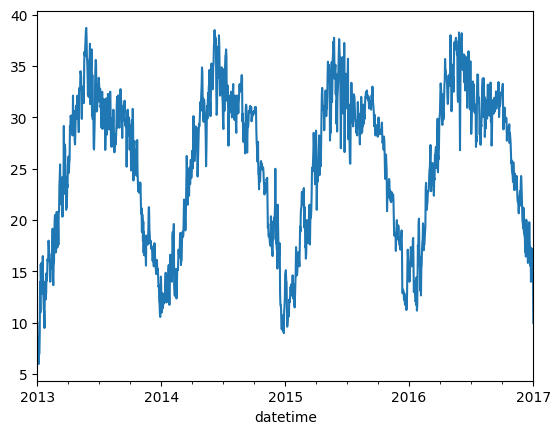

In [12]:
ax = ts.plot();

#**Figure Sizes for Time Series**

In [13]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']

[6.4, 4.8]

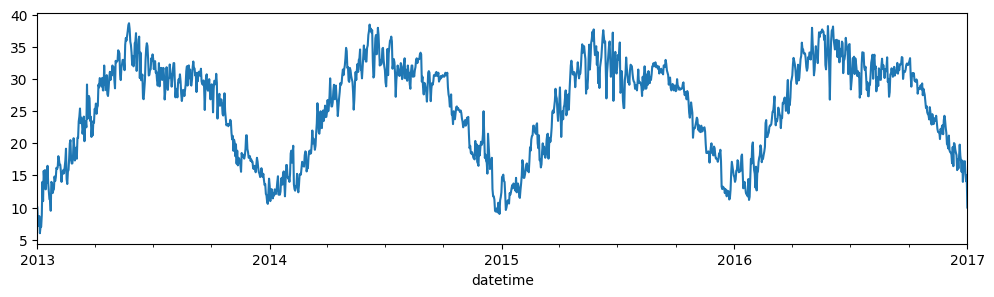

In [14]:
## plot a 12x3 figure
ts.plot(figsize=(12,3));

In [15]:
## setting the default figsize for this notebook
plt.rcParams['figure.figsize'] = (12,3)

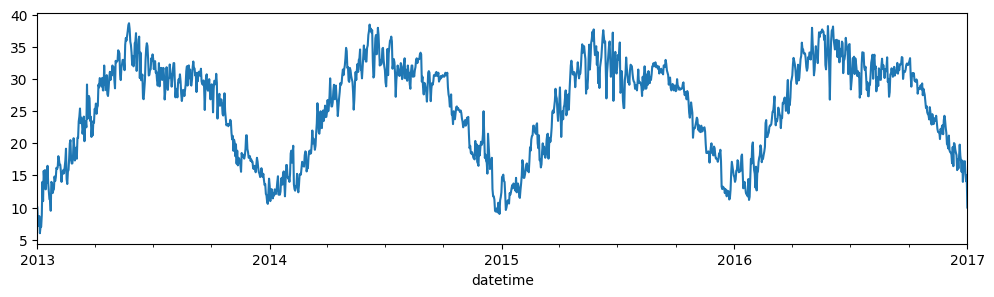

In [16]:
ax = ts.plot();

#**Plot - Style/ Level of Detail**

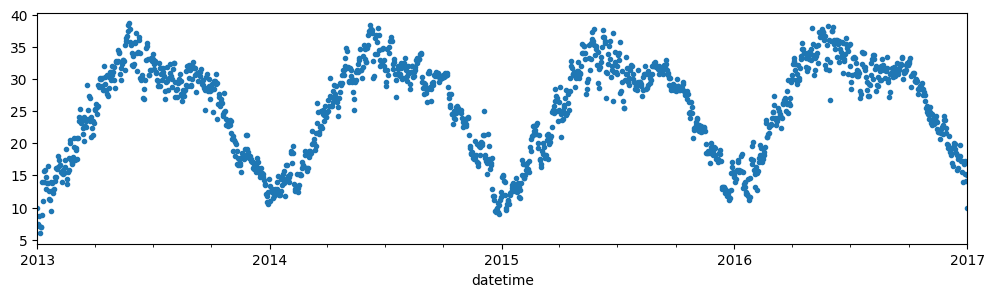

In [17]:
## we can also visualize just the markers without the line
ax = ts.plot(style='.');

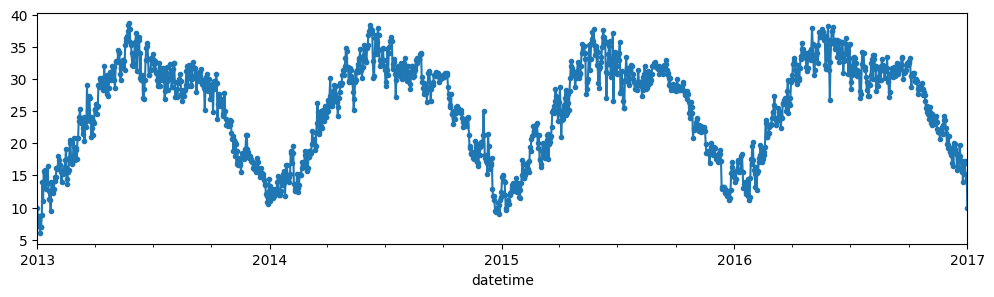

In [18]:
## Using style to add markers
ax = ts.plot(style='.-')

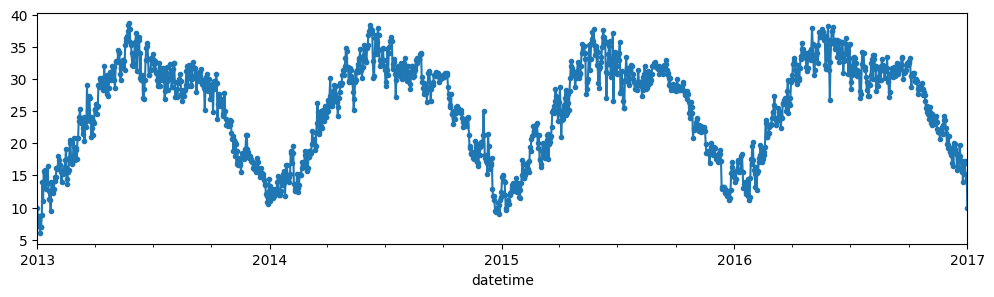

In [19]:
## Using marker to add markers
ax = ts.plot(marker='.')

#**Formatting Date Xticks**
#**Matplotlib's Artists**

In [20]:
#import tick customization tools
import matplotlib.ticker as mticks
import matplotlib.dates as mdates

In [21]:
## creating our tick locators and formatters
# create the locator to place ticks every 3 months.
loc_3months = mdates.MonthLocator(interval=3)
# create the formatter to display 3-letter month names + 2-digit year
fmt_months = mdates.DateFormatter("%B-%y")

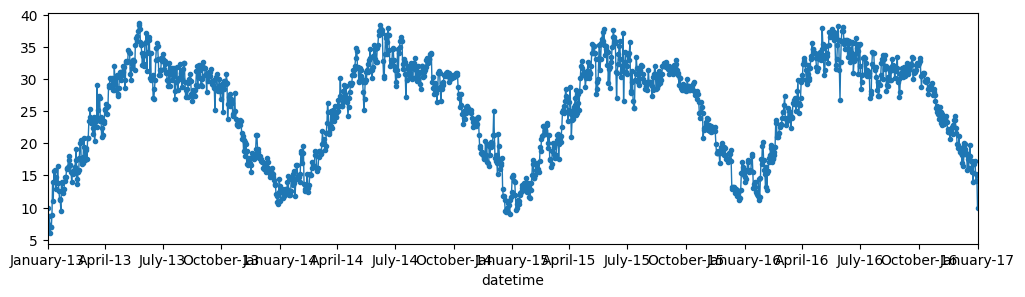

In [22]:
## Plot the time series with pandas
## Adding . markers and a thinner line
ax = ts.plot(marker='.',lw=1);
ax.xaxis.set_major_locator(loc_3months)
ax.xaxis.set_major_formatter(fmt_months)

#**Fixing Overlapping Labels**

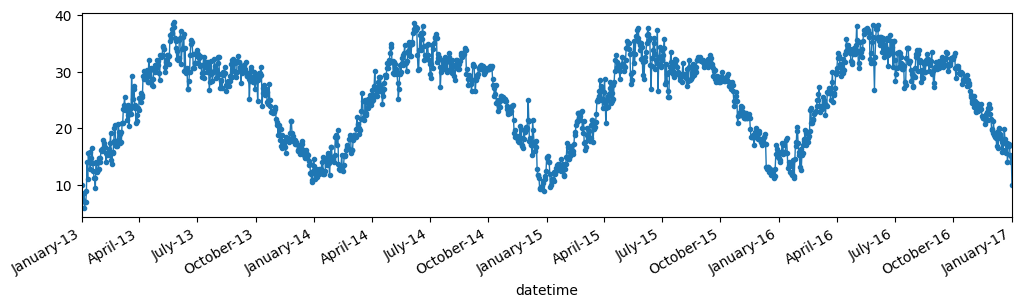

In [23]:
##  Plot the time series with pandas
ax = ts.plot(marker='.',lw=1);
ax.xaxis.set_major_locator(loc_3months)
ax.xaxis.set_major_formatter(fmt_months)
##  Using ax.get_figure()
fig = ax.get_figure()
fig.autofmt_xdate()

#**Customizing Our Ticks (advanced)**

In [24]:
## creating our tick locators and formatters
## for minor month ticks
# create the locator to place ticks every 3 months.
loc_3months = mdates.MonthLocator(interval=3)
fmt_months = mdates.DateFormatter("%b")
## for major year ticks
loc_year = mdates.YearLocator()
fmt_year = mdates.DateFormatter("%Y")

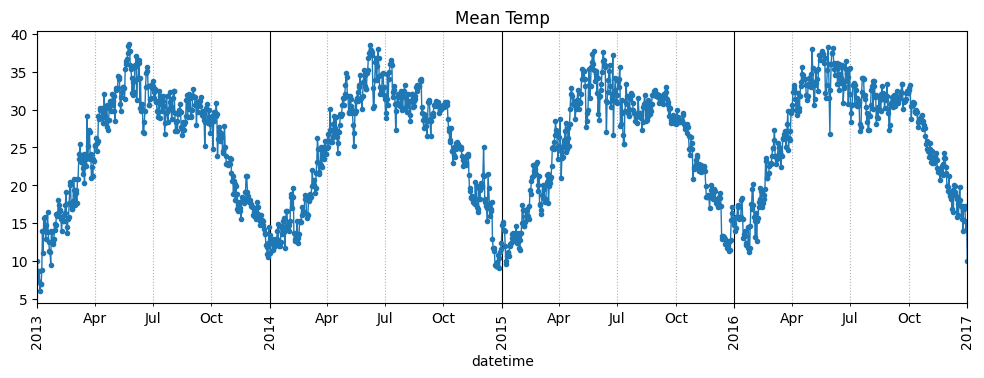

In [25]:
## Make the fig and axis first
# plot the time series with pandas
fig, ax = plt.subplots(figsize=(12,4))
ts.plot(ax=ax,title='Mean Temp',marker='.',lw=1)
## customize minor ticks
ax.xaxis.set_minor_locator(loc_3months)
ax.xaxis.set_minor_formatter(fmt_months)
## customize major ticks
ax.xaxis.set_major_locator(loc_year)
ax.xaxis.set_major_formatter(fmt_year)
## Making major/minor gridlines visually distinct
ax.grid(which='minor',axis='x',ls=":")
ax.grid(which='major',axis='x',color='k')
fig.autofmt_xdate(rotation=90,ha='center')

#**Some Additional Customizations**
#**Increasing Font Size of Major Tick Labels**

/tmp/ipykernel_4644/3965544766.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize='large',fontweight='bold' )


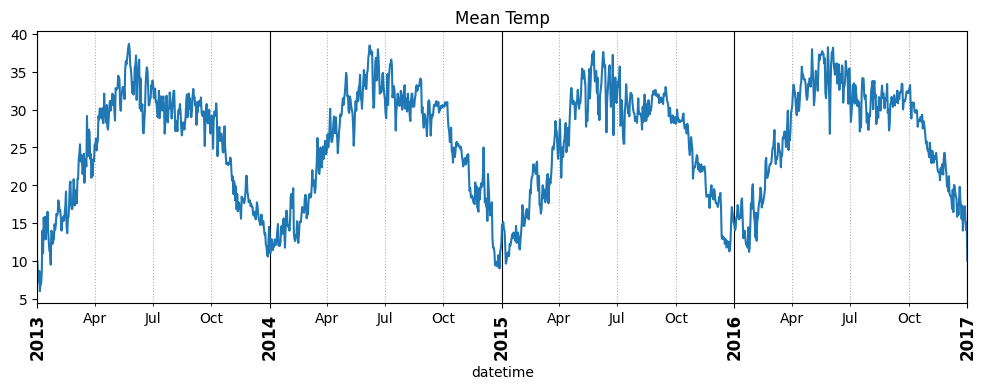

In [26]:
##  Make the fig and axis first
#  plot the time series with pandas
fig, ax = plt.subplots(figsize=(12,4))
ts.plot(ax=ax,title='Mean Temp');
##  saving current xticks
ax.set_xticklabels(ax.get_xticklabels(), fontsize='large',fontweight='bold' )
##  customize minor ticks
ax.xaxis.set_minor_locator(loc_3months)
ax.xaxis.set_minor_formatter(fmt_months)
##  customize major ticks
ax.xaxis.set_major_locator(loc_year)
ax.xaxis.set_major_formatter(fmt_year)
##  Making major/minor gridlines visually distince
ax.grid(which='minor',axis='x',ls=":")
ax.grid(which='major',axis='x',color='k')
fig.autofmt_xdate(rotation=90,ha='center')

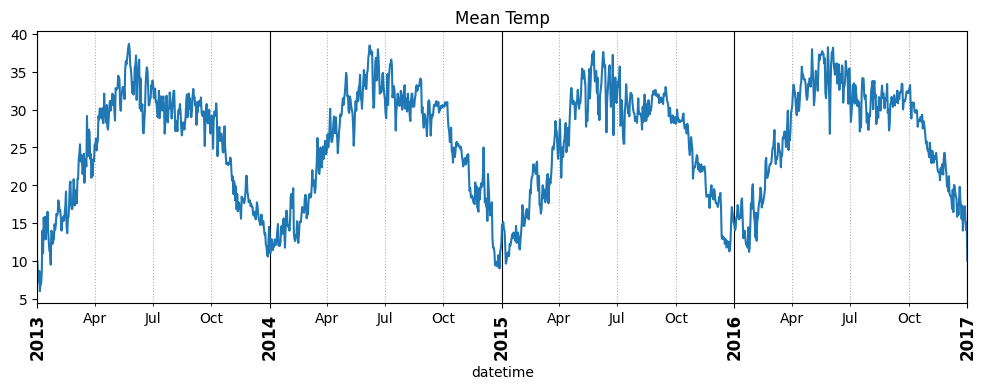

In [27]:
##  Make the fig and axis first
#  plot the time series with pandas
fig, ax = plt.subplots(figsize=(12,4))
ts.plot(ax=ax,title='Mean Temp');
##  Set xticks and xticklables
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), fontsize='large',fontweight='bold' )
##  customize minor ticks
ax.xaxis.set_minor_locator(loc_3months)
ax.xaxis.set_minor_formatter(fmt_months)
##  customize major ticks
ax.xaxis.set_major_locator(loc_year)
ax.xaxis.set_major_formatter(fmt_year)
##  Making major/minor gridlines visually distince
ax.grid(which='minor',axis='x',ls=":")
ax.grid(which='major',axis='x',color='k')
fig.autofmt_xdate(rotation=90,ha='center')

#**Creating a Function for your Code**

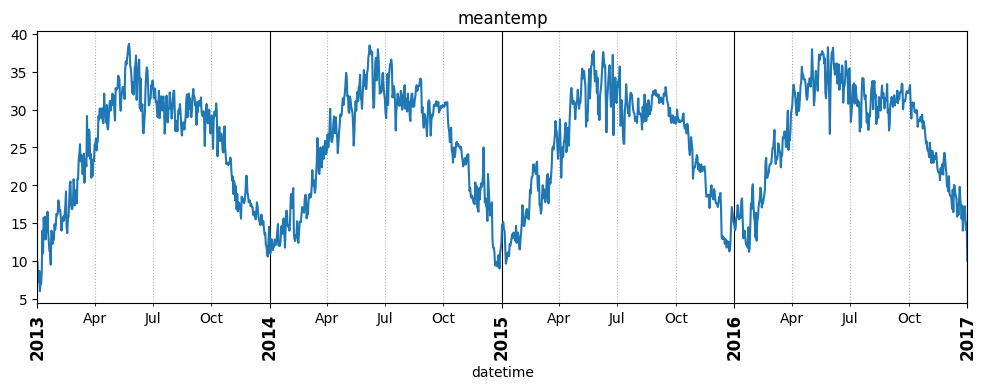

In [28]:
## we've done enough customization that it makes sense to bundle this in a function
def plot_dates(ts,figsize=(12,4),xtick_fontsize='large', xtick_fontweight='bold',
               title= None):## Make the fig and axis first

    if title is None:
        title = ts.name
    # plot the time series with pandas
    fig, ax = plt.subplots(figsize=figsize)
    ts.plot(ax=ax,title=title);

    ## creating our tick locators and formatters
    ## for minor month ticks
    # create the locator to place ticks every 3 months.
    loc_3months = mdates.MonthLocator(interval=3)
    fmt_months = mdates.DateFormatter("%b")
    ## for major year ticks
    loc_year = mdates.YearLocator()
    fmt_year = mdates.DateFormatter("%Y")

    ## Change the font of the major ticks to stand out
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(),
                       fontsize=xtick_fontsize,
                       fontweight=xtick_fontweight)

    ## customize minor ticks
    ax.xaxis.set_minor_locator(loc_3months)
    ax.xaxis.set_minor_formatter(fmt_months)
    ## customize major ticks
    ax.xaxis.set_major_locator(loc_year)
    ax.xaxis.set_major_formatter(fmt_year)
    ## Making major/minor gridlines visually distinct
    ax.grid(which='minor',axis='x',ls=":")
    ax.grid(which='major',axis='x',color='k')
    ## rotate the dates
    fig.autofmt_xdate(which='major',rotation=90,ha='center')
    return fig,ax
plot_dates(ts);

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>بترسم time series — يعني خط بيوضح كيف تغيرت درجة الحرارة اليومية على مدار 4 سنوات، المحور X تواريخ والمحور Y درجة الحرارة.</strong>
</p>

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>الـ function — آه بتجمع كل الأكواد اللي في الدرس بمكان واحد:</strong>
</p>

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>رسم الـ time series</strong>
</p>

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>minor ticks كل 3 شهور مع اسم الشهر</strong>
</p>

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>major ticks كل سنة مع رقم السنة</strong>
</p>

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>grid منقط للشهور وداكن للسنوات</strong>
</p>

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>تدوير التسميات</strong>
</p>

<p dir="rtl" style="font-size: 24px; color: #000000; font-weight: 900;">
  <strong>تكبير خط السنوات</strong>
</p>
